In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style='whitegrid')

print("Step 1: Setup ready.")


Step 1: Setup ready.


In [2]:
data_path = r"C:\Users\Lithi\OneDrive\Desktop\B6G2-08_AI_ML_PROJECT-main\data\raw\warsaw.csv"

df = pd.read_csv(data_path)

print("Step 2: Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
display(df.head())


Step 2: Dataset loaded successfully!
Dataset Shape: (10954, 11)


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,SNWD,TAVG,TMAX,TMIN
0,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-01,0.0,10.0,-8.3,NaN,NaN
1,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-02,NaN,10.0,-14.9,NaN,NaN
2,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-03,0.0,10.0,-13.6,-9.7,NaN
3,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-04,0.0,10.0,-10.5,-6.5,-13.3
4,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-05,0.0,10.0,-12.0,-8.9,-14.1


In [6]:
y = df['TAVG']

# Dropping non-numerical columns like STATION and text indicators
X = df.drop(columns=['STATION', 'DATE', 'TAVG', 'TMAX'], errors='ignore')

# Ensuring only completely numeric features are left
X = X.select_dtypes(include=[np.number])

print("Step 3 Fix: Only numeric features kept.")
print("Features Columns included:", X.columns.tolist())


Step 3 Fix: Only numeric features kept.
Features Columns included: ['LATITUDE', 'LONGITUDE', 'ELEVATION', 'PRCP', 'SNWD', 'TMIN']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Step 4 Fix: Data split updated successfully.")
print(f"Training Rows: {X_train.shape} | Testing Rows: {X_test.shape}")


Step 4 Fix: Data split updated successfully.
Training Rows: (8763, 6) | Testing Rows: (2191, 6)


In [8]:
dt_regressor = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_

print("Step 5 Fix: Hyperparameter Tuning Complete with clean dataset!")
print("Best Hyperparameters found:", grid_search.best_params_)


Step 5 Fix: Hyperparameter Tuning Complete with clean dataset!
Best Hyperparameters found: {'max_depth': 10, 'min_samples_split': 10}


In [9]:
y_pred = best_dt_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Step 6: Model Evaluation Metrics")
print(f"Coefficient of Determination (R2): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Step 6: Model Evaluation Metrics
Coefficient of Determination (R2): 0.6409
Root Mean Squared Error (RMSE): 5.2224


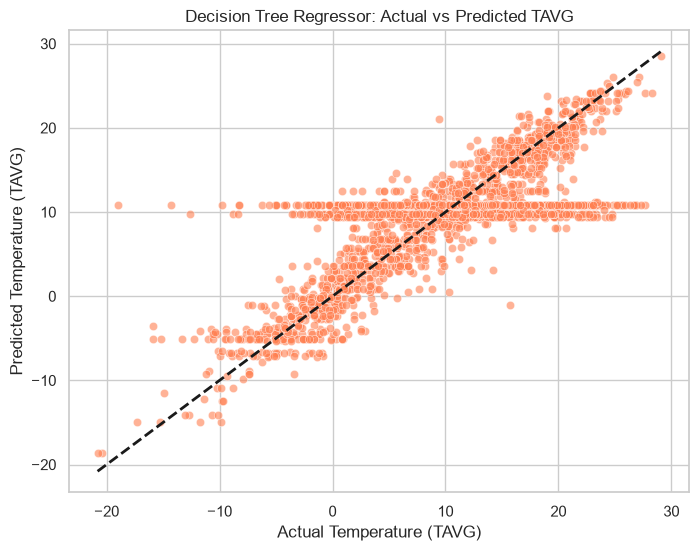

Step 7: Plot generated successfully!


In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='coral')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Temperature (TAVG)')
plt.ylabel('Predicted Temperature (TAVG)')
plt.title('Decision Tree Regressor: Actual vs Predicted TAVG')
plt.show()

print("Step 7: Plot generated successfully!")
